<a href="https://colab.research.google.com/github/Muhammad-AHMAD07/ML_Lab/blob/main/ML(Lab_6).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Required Libraries

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline

Loading Required Dataset

In [19]:
df = pd.read_csv("/content/insurance_data.csv")
df.head()


,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1


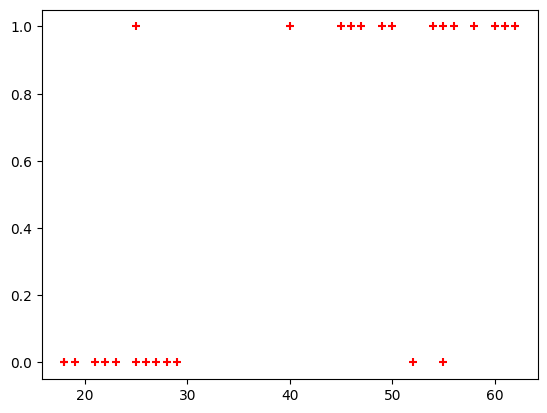

In [20]:
plt.scatter(df.age, df.bought_insurance, marker='+', color='red')

Splitting Data into Training and Testing Sets

In [40]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df[['age']],df.bought_insurance, train_size=0.8,random_state=42)

 Training the Logistic Regression Model

In [41]:
from sklearn.linear_model import LogisticRegression
model= LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

Making Predictions

In [42]:
y_predicted = model.predict(X_test)
print(y_predicted)

[1 0 1 0 0 0]


Model Evaluation

In [43]:
accuracy = model.score(X_test, y_test)
print(f"Model Accuracy: {accuracy}")

Model Accuracy: 1.0


Model Coefficients

In [44]:
import math
def sigmoid(x):
 return 1 / (1 + math.exp(-x))

Prediction Function

In [45]:
def prediction_function(age):
 z = 0.042 * age - 1.53 # Approximation of learned coefficients
 y = sigmoid(z)
 return y

print("Prediction for age 35:", prediction_function(35))
print("Prediction for age 43:", prediction_function(43))

Prediction for age 35: 0.4850044983805899
Prediction for age 43: 0.568565299077705


Tasks

Task-1 Predict Probability of Buying Insurance

In [46]:
probabilities = model.predict_proba(X_test)

print("First 5 Probability Predictions [Prob of 0, Prob of 1]:")
print(probabilities[:5])

First 5 Probability Predictions [Prob of 0, Prob of 1]:
[[0.05428672 0.94571328]
 [0.7055532  0.2944468 ]
 [0.06039333 0.93960667]
 [0.77084966 0.22915034]
 [0.84096469 0.15903531]]


Task-2 Modify Training Data Split Ratio

70-30

In [37]:
X_train, X_test, y_train, y_test = train_test_split(df[['age']], df.bought_insurance, train_size=0.7, random_state=42)


model = LogisticRegression()
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print(f"Model Accuracy with 70-30 Split: {accuracy:.2f}")

Model Accuracy with 70-30 Split: 0.89


60-40

In [39]:
X_train, X_test, y_train, y_test = train_test_split(df[['age']], df.bought_insurance, train_size=0.6, random_state=42)


model = LogisticRegression()
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print(f"Model Accuracy with 60-40 Split: {accuracy:.2f}")

Model Accuracy with 60-40 Split: 0.91


Task-3

Confusion Matrix:
[[4 0]
 [0 2]]


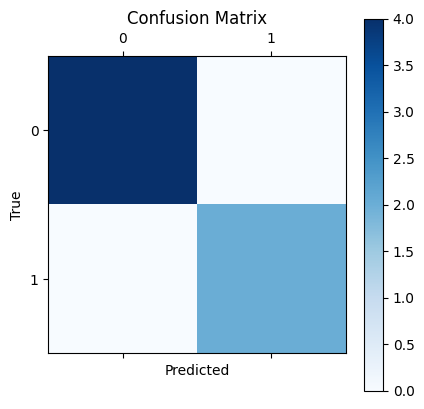

In [49]:
from sklearn.metrics import confusion_matrix
X_train, X_test, y_train, y_test = train_test_split(df[['age']], df.bought_insurance, train_size=0.8, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)
y_predicted = model.predict(X_test)
cm = confusion_matrix(y_test, y_predicted)
print("Confusion Matrix:")
print(cm)

plt.matshow(cm, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.colorbar()
plt.show()


Task-4 Visualize the Sigmoid Function

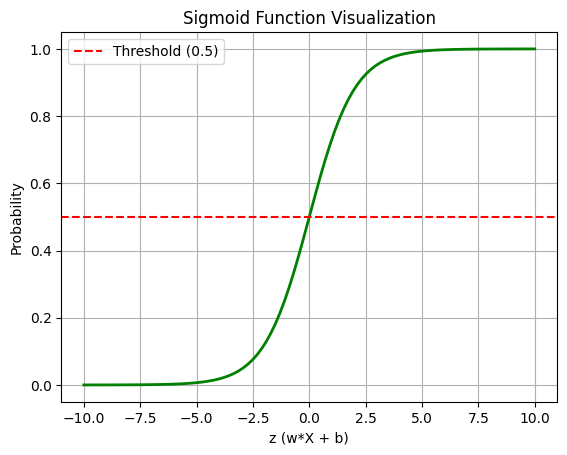

In [50]:
import numpy as np
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


z_values = np.linspace(-10, 10, 100)
sigmoid_values = sigmoid(z_values)


plt.plot(z_values, sigmoid_values, color='green', linewidth=2)
plt.axhline(0.5, color='red', linestyle='--', label='Threshold (0.5)')
plt.xlabel('z (w*X + b)')
plt.ylabel('Probability')
plt.title('Sigmoid Function Visualization')
plt.legend()
plt.grid(True)
plt.show()

Task-5 Test Model on New Data

In [55]:
X_train, X_test, y_train, y_test = train_test_split(df[['age']], df.bought_insurance, train_size=0.8, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)


new_age = [[50]]


prediction = model.predict(new_age)
prob = model.predict_proba(new_age)

print("Input Age: {new_age[0][0]}")
print(f"Predicted Class (0=No, 1=Yes): {prediction[0]}")
print(f"Probability of Buying Insurance: {prob[0][1]:.4f}")

if prediction[0] == 1:
    print("Conclusion: This person is likely to buy insurance.")
else:
    print("Conclusion: This person is NOT likely to buy insurance.")

Input Age: {new_age[0][0]}
Predicted Class (0=No, 1=Yes): 1
Probability of Buying Insurance: 0.8177
Conclusion: This person is likely to buy insurance.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
